In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [2]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [3]:
import os
import numpy as np
import pandas as pd

file_path = '/content/drive/MyDrive/Tesi_Raman/Datasets/IBD/Dataset Raman IBD Final ICSM.xlsx'
sheet_name = 'Foglio2'
print('Loading IBD Dataset...')

# 1. Read Data with Pandas
try:
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
except FileNotFoundError:
    # Fallback if the file is saved in a different folder
    file_path = '/content/drive/MyDrive/Dataset Raman IBD Final ICSM.xlsx'
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# 2. Read Wavenumbers from header row (row 0)
raw_header = df.iloc[0, :].values
NUM_META = 11

# Extract wavenumber (columns from 11 onwards, Python index)
wavenumbers_raw = pd.to_numeric(raw_header[NUM_META:], errors='coerce')
num_col_spettrali = len(wavenumbers_raw)
print(f"Wavenumbers read: {num_col_spettrali}")
print(f"Original axis range: {np.nanmin(wavenumbers_raw):.2f} - {np.nanmax(wavenumbers_raw):.2f} cm^-1")

# 3. Metadata and Labels
meta_df = df.iloc[1:, :NUM_META].copy()
meta_df.columns = raw_header[:NUM_META]

# Drop completely empty rows
meta_df = meta_df.dropna(how='all')
valid_indices = meta_df.index

# Column 4 (index 3) = IBD/HC, Column 3 (index 2) = Healthy/Sick Detail
labels_ibd_str = meta_df.iloc[:, 3].astype(str).str.strip().str.upper()
labels_detail = meta_df.iloc[:, 2].astype(str).str.strip()

labels_binary = np.zeros(len(labels_ibd_str), dtype=int)
labels_binary[labels_ibd_str.isin(['IDB', 'IBD'])] = 1

print(f"Class distribution:")
print(f"  HC  (0): {np.sum(labels_binary == 0)}")
print(f"  IBD (1): {np.sum(labels_binary == 1)}")

# 4. Spectral Matrix
X_raw_unsorted = df.iloc[valid_indices, NUM_META:].values.astype(float)
X_raw_unsorted[np.isnan(X_raw_unsorted)] = 0

# Remove all-zero rows
valid_rows = ~np.all(X_raw_unsorted == 0, axis=1)
X_raw_unsorted = X_raw_unsorted[valid_rows, :]
labels_binary = labels_binary[valid_rows]
labels_detail = labels_detail.values[valid_rows]

# 5. SORT WAVENUMBER (excel is in descending order, we need ascending)
sort_idx = np.argsort(wavenumbers_raw)
asse_X = wavenumbers_raw[sort_idx]
X_raw = X_raw_unsorted[:, sort_idx]

labels_final = labels_binary
groups_final = labels_detail # We use detailed labels instead of 'mice_ids' in this dataset

print(f"Remaining spectra after filtering: {X_raw.shape[0]}")
print(f"X axis shape: {asse_X.shape}")

Loading IBD Dataset...
Wavenumbers read: 1216
Original axis range: 403.89 - 1754.26 cm^-1
Class distribution:
  HC  (0): 93
  IBD (1): 135
Remaining spectra after filtering: 228
X axis shape: (1216,)


In [4]:
# This code is no longer necessary as the X axis is extracted from TROPHY.mat as asse_X

# def read_axis(filename):
#     """Read the wavelength axis from file."""
#     with open(filename, 'r') as f:
#         wavelengths = np.array([float(line.strip()) for line in f])
#     return wavelengths

# wavelengths = read_axis("/content/drive/My Drive/ramandata/conor/axis.txt")


In [5]:
from scipy import interpolate
from tqdm import tqdm

# Global parameters for the new wavelength axis
MIN_WAVE = 650
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
asse_target = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)
print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

def interpolate_spectra(spectra_data, old_wavelengths, new_wavelengths_target):
    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], len(new_wavelengths_target)))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to new wavelength points
        interpolated_spectra[i, :] = f(new_wavelengths_target)

    return interpolated_spectra, new_wavelengths_target

New target axis created: from 650 to 1750 with 1000 points.


In [6]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        # Min-max normalization to [0,1] range
        normalized[i, :] = (spectrum - min_val) / (max_val - min_val)

    return normalized

In [7]:
# Adapt the X axis in 1D format
asse_X_flat = asse_X.flatten()

# Use predefined target axis
interpolated_spectra, new_wavelengths = interpolate_spectra(
    X_raw,
    asse_X_flat,
    asse_target
)

100%|██████████| 228/228 [00:00<00:00, 2756.38it/s]


In [8]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 228/228 [00:00<00:00, 37755.19it/s]


(228, 1000)

In [9]:
import os

# Requested save path
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create folder if it doesn't exist

save_path = os.path.join(save_dir, 'IBD_1000pt_FingerPrint.npz')

# Save normalized spectra, new x axis, labels and groups
# Cast to float32 to reduce file size
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32),
          labels=labels_final,
          groups=groups_final)

print(f"Standardized IBD dataset saved in: {save_path} (float32)")

Standardized IBD dataset saved in: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz (float32)


In [10]:
import numpy as np

# Check the newly saved file
print("--- SAVED FILE VERIFICATION ---")
loaded_data = np.load(save_path)
loaded_wavelengths = loaded_data['wavelengths']
loaded_spectra = loaded_data['spectra']

print(f"File loaded from: {save_path}")
print(f"Spectra matrix dimensions: {loaded_spectra.shape}")
print(f"Number of points in X axis: {len(loaded_wavelengths)}")
print(f"Exact X axis range: from {loaded_wavelengths.min():.2f} to {loaded_wavelengths.max():.2f} cm^-1")

--- SAVED FILE VERIFICATION ---
File loaded from: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz
Spectra matrix dimensions: (228, 1000)
Number of points in X axis: 1000
Exact X axis range: from 650.00 to 1750.00 cm^-1


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [11]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [12]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

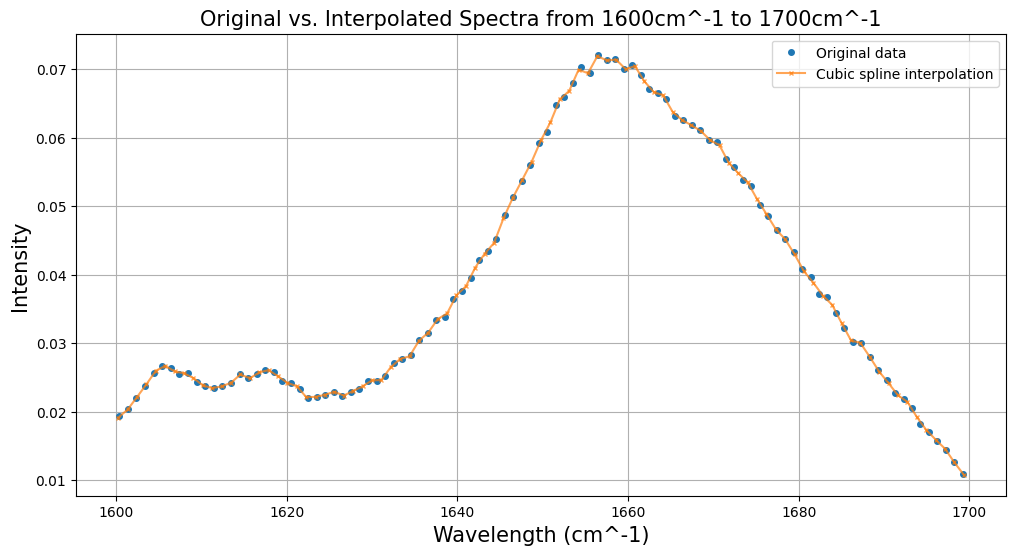

In [13]:
wavelength_range = (1600,1700) # Modified to use global bounds
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4) # Markersize reduced to better visualize numerous points
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3) # Restored 'x' marker for interpolated points

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

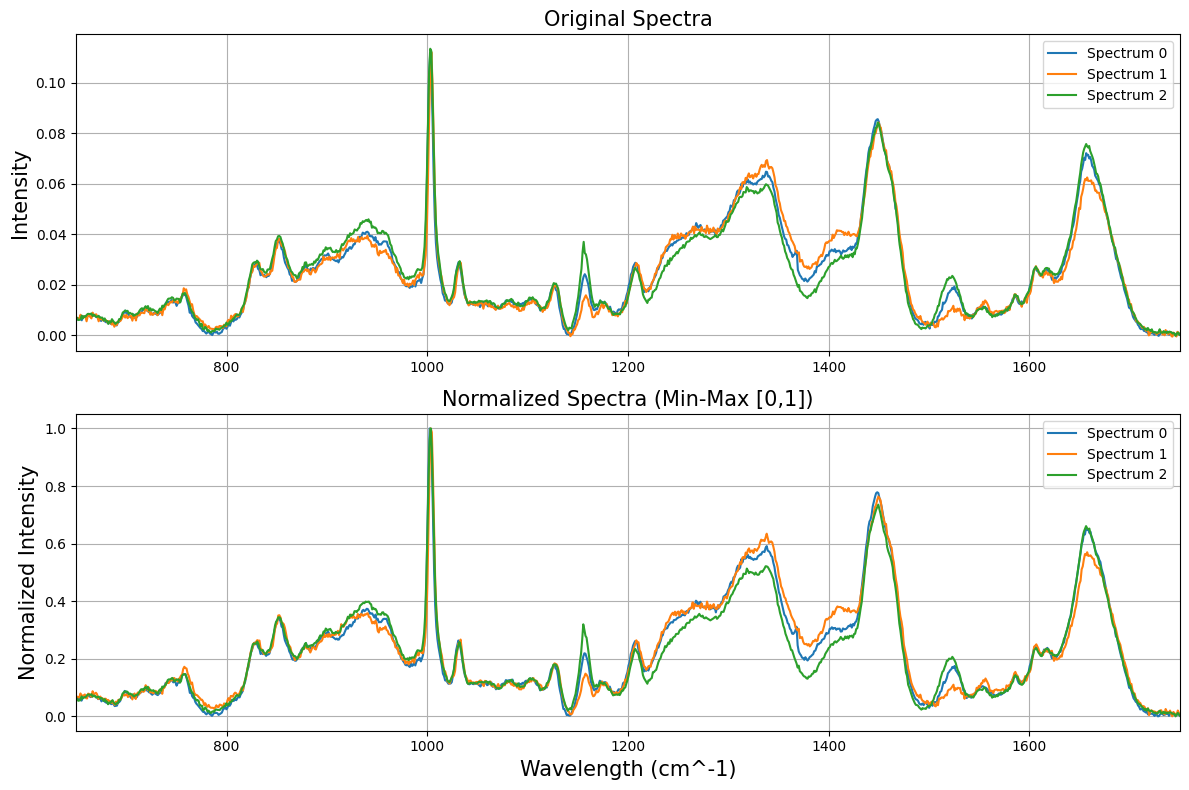

In [14]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    # ax1.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.set_xlim([MIN_WAVE, MAX_WAVE])
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.set_xlim([MIN_WAVE, MAX_WAVE])
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

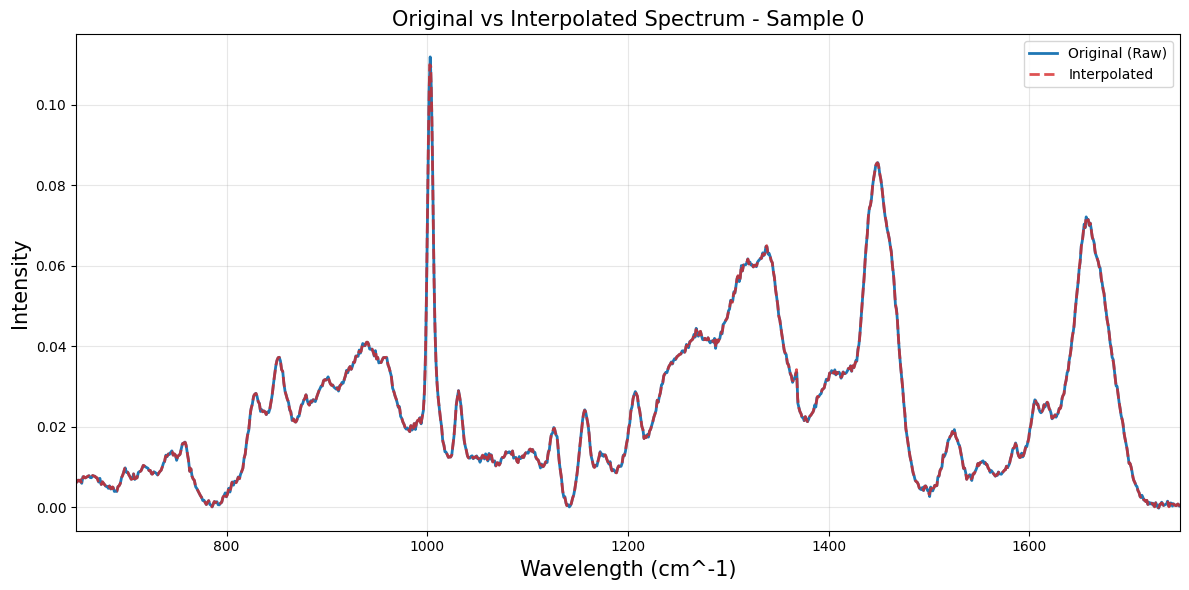

In [15]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)

# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red',
         linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()